# 2d plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os

import sys
sys.path.append("..")

from sources.simulation import *
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

In [2]:
from pathlib import Path
import subprocess

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from sources.simulation import disk_boundary


# ============================================================
# Report output directory
# ============================================================

PROJECT_ROOT = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"],
        text=True
    ).strip()
)

REPORT_2D_DIR = PROJECT_ROOT / "report_2dplots"
REPORT_2D_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Base plotting values
# ============================================================

BASE_FONT_SIZE = 10
BASE_TICK_SIZE = 9
BASE_LEGEND_SIZE = 9

BASE_LINEWIDTH = 1.5
BASE_MARKERSIZE = 4.5

BASE_AXES_LINEWIDTH = 0.8
BASE_MAJOR_TICK_WIDTH = 0.8
BASE_MINOR_TICK_WIDTH = 0.6

BASE_GRID_LINEWIDTH = 0.5


# ============================================================
# Dissertation plotting style
# ============================================================

mpl.rcParams.update({

    # LaTeX / fonts
    "text.usetex": True,
    "font.family": "serif",

    "font.size": BASE_FONT_SIZE,
    "axes.titlesize": BASE_FONT_SIZE,
    "axes.labelsize": BASE_FONT_SIZE,
    "xtick.labelsize": BASE_TICK_SIZE,
    "ytick.labelsize": BASE_TICK_SIZE,
    "legend.fontsize": BASE_LEGEND_SIZE,

    # Axes
    "axes.linewidth": BASE_AXES_LINEWIDTH,
    "axes.axisbelow": True,

    # Lines
    "lines.linewidth": BASE_LINEWIDTH,
    "lines.markersize": BASE_MARKERSIZE,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",

    "xtick.major.width": BASE_MAJOR_TICK_WIDTH,
    "ytick.major.width": BASE_MAJOR_TICK_WIDTH,

    "xtick.minor.width": BASE_MINOR_TICK_WIDTH,
    "ytick.minor.width": BASE_MINOR_TICK_WIDTH,

    # Grid
    "grid.alpha": 0.22,
    "grid.linewidth": BASE_GRID_LINEWIDTH,

    # Legends
    "legend.frameon": False,

    # Display / saving
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "savefig.facecolor": "white",
})


# ============================================================
# Consistent colours
# ============================================================

COLOR_REFLECTION = "tab:blue"
COLOR_REJECTION = "tab:orange"
COLOR_STATIONARY = "red"
COLOR_DOMAIN_BOUNDARY = "tab:blue"

STATIONARY_ALPHA = 0.90

REPORT_CMAP = mpl.colormaps["viridis"]


# ============================================================
# Base figure sizes
# ============================================================

# Line / convergence figures
FIGSIZE_SINGLE = (6.2, 3.8)
FIGSIZE_DOUBLE = (7.2, 3.6)

# 2D fields
FIGSIZE_2D_TRIPLE = (9.6, 3.4)
FIGSIZE_2D_2X2 = (7.2, 6.0)

# Long polar / boundary-strip heatmaps
FIGSIZE_2D_STRIP = (7.2, 3.4)


# ============================================================
# Uniform figure scaling
# ============================================================

def scaled_figsize(figsize, scale=1.0):
    return tuple(value * scale for value in figsize)


def scaled_plot_style(scale=1.0):
    """
    Scale the complete visual appearance of a figure uniformly.
    """

    return {
        "font.size": BASE_FONT_SIZE * scale,
        "axes.titlesize": BASE_FONT_SIZE * scale,
        "axes.labelsize": BASE_FONT_SIZE * scale,

        "xtick.labelsize": BASE_TICK_SIZE * scale,
        "ytick.labelsize": BASE_TICK_SIZE * scale,
        "legend.fontsize": BASE_LEGEND_SIZE * scale,

        "lines.linewidth": BASE_LINEWIDTH * scale,
        "lines.markersize": BASE_MARKERSIZE * scale,

        "axes.linewidth": BASE_AXES_LINEWIDTH * scale,

        "xtick.major.width": BASE_MAJOR_TICK_WIDTH * scale,
        "ytick.major.width": BASE_MAJOR_TICK_WIDTH * scale,

        "xtick.minor.width": BASE_MINOR_TICK_WIDTH * scale,
        "ytick.minor.width": BASE_MINOR_TICK_WIDTH * scale,

        "grid.linewidth": BASE_GRID_LINEWIDTH * scale,
    }


# ============================================================
# Saving
# ============================================================

def save_report_2d_figure(
    fig,
    filename,
    save_png=True
):
    """
    Save a report figure as PDF and optionally PNG.
    """

    fig.savefig(
        REPORT_2D_DIR / f"{filename}.pdf"
    )

    if save_png:
        fig.savefig(
            REPORT_2D_DIR / f"{filename}.png",
            dpi=300
        )


# ============================================================
# Report-only shared colourbar
# ============================================================

def report_add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=REPORT_CMAP,
    label=r"Density",
    gap=0.018,
    width=0.015
):
    """
    Add one shared colourbar to the right of a group of axes.
    Its position is determined from the final subplot geometry.
    """

    vmin, vmax = colorbar_values

    mappable = ScalarMappable(
        norm=Normalize(vmin=vmin, vmax=vmax),
        cmap=cmap
    )

    # Convert axes to a flat list
    if isinstance(ax, np.ndarray):
        axes = ax.ravel().tolist()
    else:
        axes = [ax]

    # Finalise subplot positions, including equal-aspect adjustments
    fig.canvas.draw()

    # Actual bounding box of all plotted axes
    right = max(a.get_position().x1 for a in axes)
    bottom = min(a.get_position().y0 for a in axes)
    top = max(a.get_position().y1 for a in axes)

    # Dedicated colourbar axis
    cax = fig.add_axes([
        right + gap,
        bottom,
        width,
        top - bottom
    ])

    cbar = fig.colorbar(
        mappable,
        cax=cax
    )

    cbar.set_label(
        label,
        labelpad=8
    )

    return cbar
# ============================================================
# Report-only 2D field plotting
# ============================================================

def report_plot_density_mesh(
    p,
    x_edges,
    y_edges,
    ax=None,
    title=None,
    colorbar_values=None,
    cmap=REPORT_CMAP,
    x_label=r"$x_1$",
    y_label=r"$x_2$",
    equal_aspect=False
):
    """
    Plot a report-quality 2D field.

    The heatmap itself is rasterized while axes, labels,
    titles and other Matplotlib artists remain vector in PDF.
    """

    if ax is None:
        ax = plt.gca()

    if colorbar_values is None:
        vmin = None
        vmax = None
    else:
        vmin, vmax = colorbar_values

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        p.T,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        rasterized=True
    )

    if title is not None:
        ax.set_title(title)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if equal_aspect:
        ax.set_aspect("equal")

    ax.grid(False)

    return mesh


# ============================================================
# Rectangular domains
# ============================================================

def report_plot_density_2d(
    p,
    bounds,
    ax=None,
    title=None,
    colorbar_values=None,
    cmap=REPORT_CMAP
):
    """
    Plot a rectangular Cartesian density field.
    """

    if ax is None:
        ax = plt.gca()

    x_edges = np.linspace(
        bounds[0][0],
        bounds[0][1],
        p.shape[0] + 1
    )

    y_edges = np.linspace(
        bounds[1][0],
        bounds[1][1],
        p.shape[1] + 1
    )

    mesh = report_plot_density_mesh(
        p,
        x_edges,
        y_edges,
        ax=ax,
        title=title,
        colorbar_values=colorbar_values,
        cmap=cmap,
        x_label=r"$x_1$",
        y_label=r"$x_2$",
        equal_aspect=True
    )

    ax.set_xlim(bounds[0])
    ax.set_ylim(bounds[1])

    return mesh


# ============================================================
# Disk domains
# ============================================================

def report_plot_disk_boundary(
    ax=None,
    radius=1.0,
    n_points=400
):
    """
    Draw the physical boundary of a disk.
    """

    if ax is None:
        ax = plt.gca()

    theta = np.linspace(
        0,
        2 * np.pi,
        n_points
    )

    x_boundary, y_boundary = disk_boundary(
        theta=theta,
        radius=radius
    )

    line, = ax.plot(
        x_boundary,
        y_boundary,
        color=COLOR_DOMAIN_BOUNDARY
    )

    return line


def report_plot_density_disk(
    p,
    x_edges,
    y_edges,
    radius=1.0,
    ax=None,
    title=None,
    colorbar_values=None,
    cmap=REPORT_CMAP,
    show_boundary=True
):
    """
    Plot a Cartesian density field restricted to a disk.
    """

    if ax is None:
        ax = plt.gca()

    mesh = report_plot_density_mesh(
        p,
        x_edges,
        y_edges,
        ax=ax,
        title=title,
        colorbar_values=colorbar_values,
        cmap=cmap,
        x_label=r"$x_1$",
        y_label=r"$x_2$",
        equal_aspect=True
    )

    if show_boundary:
        report_plot_disk_boundary(
            ax=ax,
            radius=radius
        )

    ax.set_xlim(-radius, radius)
    ax.set_ylim(-radius, radius)

    return mesh


# ============================================================
# Polar / boundary-strip fields
# ============================================================

def report_plot_density_polar(
    p,
    theta_edges,
    r_edges,
    ax=None,
    title=None,
    colorbar_values=None,
    cmap=REPORT_CMAP
):
    """
    Plot a density or error field in (theta, r) coordinates.
    """

    if ax is None:
        ax = plt.gca()

    mesh = report_plot_density_mesh(
        p,
        theta_edges,
        r_edges,
        ax=ax,
        title=title,
        colorbar_values=colorbar_values,
        cmap=cmap,
        x_label=r"$\theta$",
        y_label=r"$r$",
        equal_aspect=False
    )

    ax.set_xlim(
        theta_edges[0],
        theta_edges[-1]
    )

    ax.set_ylim(
        r_edges[0],
        r_edges[-1]
    )

    return mesh


# ============================================================
# Report-only radial slices
# ============================================================

def report_plot_radial_slice(
    r,
    values,
    ax=None,
    title=None,
    label=None,
    color=None,
    y_label=r"Value",
    marker="x",
    linestyle="-"
):
    """
    Plot values along a radial slice.
    """

    if ax is None:
        ax = plt.gca()

    ax.plot(
        r,
        values,
        marker=marker,
        linestyle=linestyle,
        color=color,
        label=label
    )

    if title is not None:
        ax.set_title(title)

    ax.set_xlabel(r"$r$")
    ax.set_ylabel(y_label)

    ax.grid(True)

    return ax

## box domain

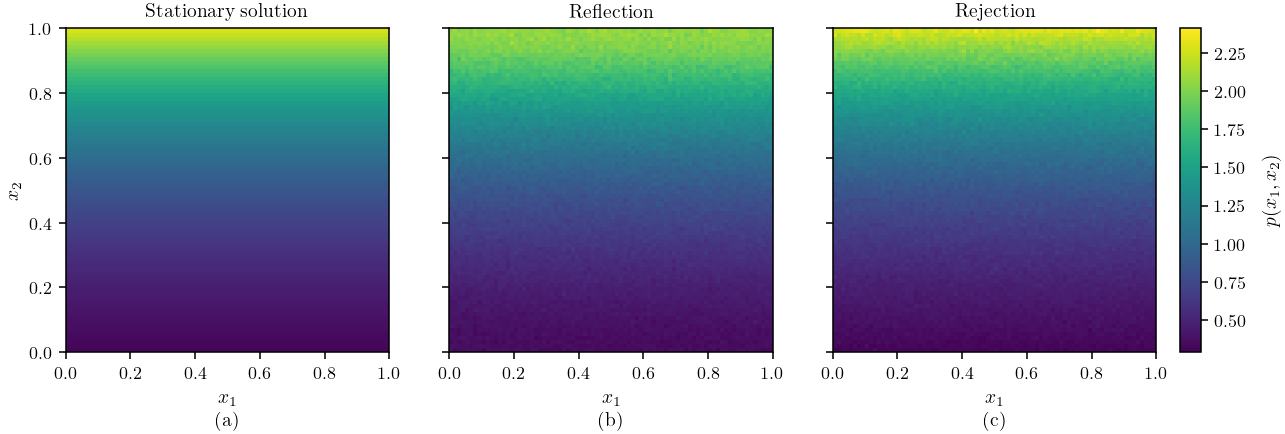

In [3]:
# Rectangular-domain validation
# Stationary solution, reflection and rejection

bounds = ((0, 1), (0, 1))
b = np.array([0.0, 1.0])
sigma = np.eye(2)

dt = 0.01
bins = 80

problem_path = "./data/rectangle_b-0-1_s-I"

boundary_types = [
    "reflection",
    "rejection"
]

titles = {
    "exact": "Stationary solution",
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [
    r"(a)",
    r"(b)",
    r"(c)"
]

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Common Cartesian grid
# ============================================================

x_edges = np.linspace(
    bounds[0][0],
    bounds[0][1],
    bins + 1
)

y_edges = np.linspace(
    bounds[1][0],
    bounds[1][1],
    bins + 1
)

x_centres = 0.5 * (
    x_edges[:-1] + x_edges[1:]
)

y_centres = 0.5 * (
    y_edges[:-1] + y_edges[1:]
)

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)


# ============================================================
# Stationary solution
# ============================================================

p_exact = stationary_solution_2d(
    x_mesh,
    y_mesh,
    b,
    sigma,
    bounds
)

density_data = {
    "exact": p_exact
}

p_scales = [
    p_exact
]


# ============================================================
# Numerical densities
# ============================================================

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, _, _ = np.histogram2d(
        X[:, 0],
        X[:, 1],
        bins=[
            x_edges,
            y_edges
        ],
        density=True
    )

    density_data[boundary_type] = p_num
    p_scales.append(p_num)


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = get_colorbar_values_2d(
    p_scales
)


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        1,
        3,
        figsize=scaled_figsize(
            FIGSIZE_2D_TRIPLE,
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    # Stationary solution
    report_plot_density_2d(
        density_data["exact"],
        bounds,
        ax=ax[0],
        title=titles["exact"],
        colorbar_values=colorbar_values,
        cmap=cmap
    )

    # Reflection and rejection
    for i, boundary_type in enumerate(
        boundary_types
    ):

        report_plot_density_2d(
            density_data[boundary_type],
            bounds,
            ax=ax[i + 1],
            title=titles[boundary_type],
            colorbar_values=colorbar_values,
            cmap=cmap
        )

    # --------------------------------------------------------
    # Axis labels and formatting
    # --------------------------------------------------------

    for a in ax:

        a.set_xlabel(r"$x_1$")
        a.set_ylabel("")
        a.set_aspect("equal")

    ax[0].set_ylabel(r"$x_2$")


    # --------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------

    for i, label in enumerate(
        panel_labels
    ):

        ax[i].text(
            0.5,
            -0.18,
            label,
            transform=ax[i].transAxes,
            ha="center",
            va="top"
        )


    # --------------------------------------------------------
    # Final subplot layout
    #
    # Leave room on the right for the colourbar.
    # --------------------------------------------------------

    fig.subplots_adjust(
        left=0.07,
        right=0.90,
        top=0.88,
        bottom=0.20,
        wspace=0.10
    )


    # --------------------------------------------------------
    # Shared colourbar
    # --------------------------------------------------------

    report_add_shared_colorbar(
        fig,
        ax,
        colorbar_values,
        cmap=cmap,
        label=r"$p(x_1, x_2)$",
        gap=0.018,
        width=0.015
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    save_report_2d_figure(
        fig,
        f"box_ref_rej_dt-{dt:g}"
    )

    plt.show()
    plt.close(fig)

## Disk

### isotropic case

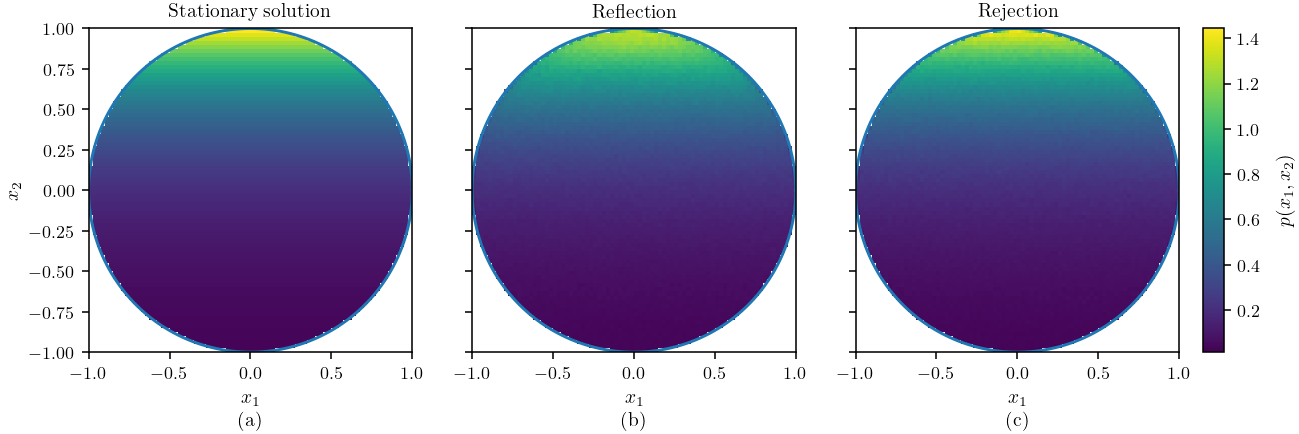

In [4]:
# Isotropic diffusion in the unit disk
# Stationary solution, reflection and rejection

radius = 1.0
dt = 0.01
bins = 80

b = np.array([0.0, 1.0])
sigma = np.eye(2)

problem_path = "./data/disk_b-0-1_s-I"

boundary_types = [
    "reflection",
    "rejection"
]

titles = {
    "exact": "Stationary solution",
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [
    r"(a)",
    r"(b)",
    r"(c)"
]

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Cartesian grid
# ============================================================

x_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

y_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

x_centres = 0.5 * (
    x_edges[:-1] + x_edges[1:]
)

y_centres = 0.5 * (
    y_edges[:-1] + y_edges[1:]
)

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)


# ============================================================
# Stationary reference solution
# ============================================================

p_exact = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)

density_data = {
    "exact": p_exact
}

p_scales = [
    p_exact
]


# ============================================================
# Numerical densities
# ============================================================

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, _, _ = histogram_density_disk(
        X,
        radius=radius,
        bins=bins
    )

    density_data[boundary_type] = p_num
    p_scales.append(p_num)


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = get_colorbar_values_2d(
    p_scales
)


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        1,
        3,
        figsize=scaled_figsize(
            FIGSIZE_2D_TRIPLE,
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    # Stationary solution
    report_plot_density_disk(
        density_data["exact"],
        x_edges,
        y_edges,
        radius=radius,
        ax=ax[0],
        title=titles["exact"],
        colorbar_values=colorbar_values,
        cmap=cmap
    )

    # Reflection and rejection
    for i, boundary_type in enumerate(
        boundary_types
    ):

        report_plot_density_disk(
            density_data[boundary_type],
            x_edges,
            y_edges,
            radius=radius,
            ax=ax[i + 1],
            title=titles[boundary_type],
            colorbar_values=colorbar_values,
            cmap=cmap
        )

    # --------------------------------------------------------
    # Axis labels and formatting
    # --------------------------------------------------------

    for a in ax:
        a.set_xlabel(r"$x_1$")
        a.set_ylabel("")
        a.set_aspect("equal")

    ax[0].set_ylabel(r"$x_2$")


    # --------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------

    for i, label in enumerate(
        panel_labels
    ):

        ax[i].text(
            0.5,
            -0.18,
            label,
            transform=ax[i].transAxes,
            ha="center",
            va="top"
        )


    # --------------------------------------------------------
    # Final subplot layout
    # --------------------------------------------------------

    fig.subplots_adjust(
        left=0.07,
        right=0.90,
        top=0.88,
        bottom=0.20,
        wspace=0.10
    )


    # --------------------------------------------------------
    # Shared colourbar
    # --------------------------------------------------------

    report_add_shared_colorbar(
        fig,
        ax,
        colorbar_values,
        cmap=cmap,
        label=r"$p(x_1, x_2)$",
        gap=0.018,
        width=0.015
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    save_report_2d_figure(
        fig,
        f"b-0-1_s-I_iso_dt-{dt:g}"
    )

    plt.show()
    plt.close(fig)

### anisotropic

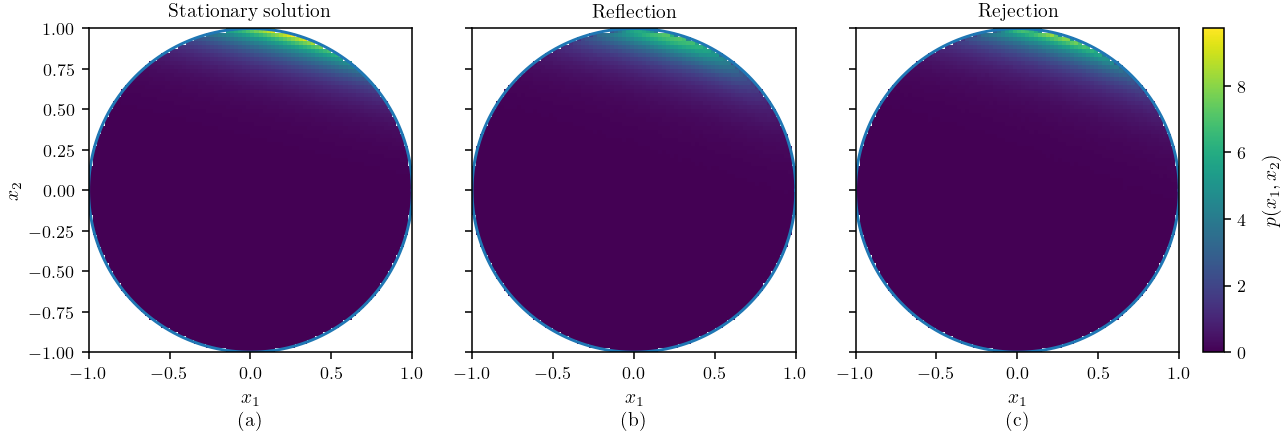

In [5]:
# Anisotropic diffusion in the unit disk
# Stationary solution, reflection and rejection

radius = 1.0
dt = 0.01
bins = 80

b = np.array([1.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

titles = {
    "exact": "Stationary solution",
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [
    r"(a)",
    r"(b)",
    r"(c)"
]

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Cartesian grid
# ============================================================

x_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

y_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

x_centres = 0.5 * (
    x_edges[:-1] + x_edges[1:]
)

y_centres = 0.5 * (
    y_edges[:-1] + y_edges[1:]
)

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)


# ============================================================
# Stationary reference solution
# ============================================================

p_exact = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)

density_data = {
    "exact": p_exact
}

p_scales = [
    p_exact
]


# ============================================================
# Numerical densities
# ============================================================

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, _, _ = histogram_density_disk(
        X,
        radius=radius,
        bins=bins
    )

    density_data[boundary_type] = p_num
    p_scales.append(p_num)


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = get_colorbar_values_2d(
    p_scales
)


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        1,
        3,
        figsize=scaled_figsize(
            FIGSIZE_2D_TRIPLE,
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    # Stationary solution
    report_plot_density_disk(
        density_data["exact"],
        x_edges,
        y_edges,
        radius=radius,
        ax=ax[0],
        title=titles["exact"],
        colorbar_values=colorbar_values,
        cmap=cmap
    )

    # Reflection and rejection
    for i, boundary_type in enumerate(boundary_types):

        report_plot_density_disk(
            density_data[boundary_type],
            x_edges,
            y_edges,
            radius=radius,
            ax=ax[i + 1],
            title=titles[boundary_type],
            colorbar_values=colorbar_values,
            cmap=cmap
        )

    # --------------------------------------------------------
    # Axis labels and formatting
    # --------------------------------------------------------

    for a in ax:
        a.set_xlabel(r"$x_1$")
        a.set_ylabel("")
        a.set_aspect("equal")

    ax[0].set_ylabel(r"$x_2$")


    # --------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------

    for i, label in enumerate(panel_labels):
        ax[i].text(
            0.5,
            -0.18,
            label,
            transform=ax[i].transAxes,
            ha="center",
            va="top"
        )


    # --------------------------------------------------------
    # Final subplot layout
    # --------------------------------------------------------

    fig.subplots_adjust(
        left=0.07,
        right=0.90,
        top=0.88,
        bottom=0.20,
        wspace=0.10
    )


    # --------------------------------------------------------
    # Shared colourbar
    # --------------------------------------------------------

    report_add_shared_colorbar(
        fig,
        ax,
        colorbar_values,
        cmap=cmap,
        label=r"$p(x_1, x_2)$",
        gap=0.018,
        width=0.015
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    save_report_2d_figure(
        fig,
        f"aniso_base_dt-{dt:g}"
    )

    plt.show()
    plt.close(fig)

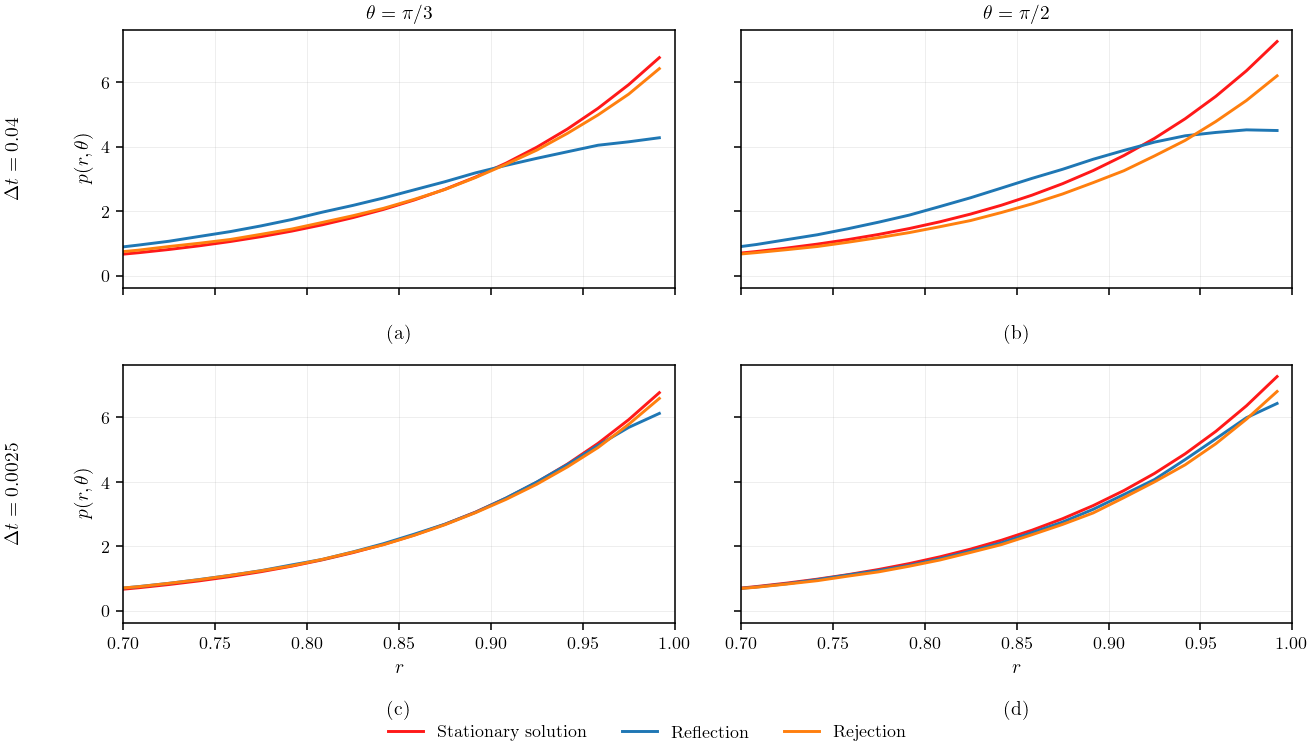

In [6]:
# Anisotropic diffusion in the unit disk
# Radial slices for two time steps and two angles

radius = 1.0

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

dt_list = [
    0.04,
    0.0025
]

theta_list = [
    np.pi / 3,
    np.pi / 2
]

theta_labels = [
    r"$\theta = \pi/3$",
    r"$\theta = \pi/2$"
]

panel_labels = [
    [r"(a)", r"(b)"],
    [r"(c)", r"(d)"]
]

# Figure-specific scale
figure_scale = 1.0


# ============================================================
# Radial discretisation
# ============================================================

n_r = 60

r_edges = np.linspace(
    0.0,
    radius,
    n_r + 1
)

r_centres = 0.5 * (
    r_edges[:-1] + r_edges[1:]
)

# Angular half-width of the sampling wedge
delta_theta = np.pi / 36


# ============================================================
# Radial-slice helpers
# ============================================================

def angle_distance(theta, theta0):
    """
    Smallest absolute angular distance between theta and theta0.
    """
    return np.abs(
        np.angle(
            np.exp(
                1j * (theta - theta0)
            )
        )
    )


def radial_density_slice(
    X,
    theta0,
    r_edges,
    delta_theta
):
    """
    Estimate the 2D density along a radial slice by averaging
    over a thin angular wedge around theta0.
    """

    x1 = X[:, 0]
    x2 = X[:, 1]

    r = np.sqrt(
        x1**2 + x2**2
    )

    theta = np.mod(
        np.arctan2(x2, x1),
        2 * np.pi
    )

    mask_theta = (
        angle_distance(theta, theta0)
        <= delta_theta
    )

    r_sel = r[mask_theta]

    counts, _ = np.histogram(
        r_sel,
        bins=r_edges
    )

    # Area of each annular-sector bin with
    # angular width 2 * delta_theta
    area = delta_theta * (
        r_edges[1:]**2
        - r_edges[:-1]**2
    )

    density = counts / (
        X.shape[0] * area
    )

    return density


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        2,
        2,
        figsize=scaled_figsize(
            (9.6, 5.8),
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    ax = np.atleast_2d(ax)

    stationary_line = None
    reflection_line = None
    rejection_line = None


    for row, dt in enumerate(dt_list):

        # Load numerical solutions
        X_ref = load_solution(
            f"reflection_dt-{dt}.npy",
            problem_path
        )

        X_rej = load_solution(
            f"rejection_dt-{dt}.npy",
            problem_path
        )


        for col, (theta0, theta_label) in enumerate(
            zip(theta_list, theta_labels)
        ):

            # ------------------------------------------------
            # Exact radial profile
            # ------------------------------------------------

            x_curve = (
                r_centres * np.cos(theta0)
            )

            y_curve = (
                r_centres * np.sin(theta0)
            )

            p_exact = stationary_solution_disk(
                x_curve,
                y_curve,
                b,
                sigma,
                radius=radius
            )


            # ------------------------------------------------
            # Numerical radial profiles
            # ------------------------------------------------

            p_ref = radial_density_slice(
                X_ref,
                theta0,
                r_edges,
                delta_theta
            )

            p_rej = radial_density_slice(
                X_rej,
                theta0,
                r_edges,
                delta_theta
            )


            # ------------------------------------------------
            # Plot profiles
            # ------------------------------------------------

            stationary_line, = ax[row, col].plot(
                r_centres,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            reflection_line, = ax[row, col].plot(
                r_centres,
                p_ref,
                color=COLOR_REFLECTION,
                label=r"Reflection"
            )

            rejection_line, = ax[row, col].plot(
                r_centres,
                p_rej,
                color=COLOR_REJECTION,
                label=r"Rejection"
            )


            # ------------------------------------------------
            # Axes formatting
            # ------------------------------------------------

            if row == 0:
                ax[row, col].set_title(
                    theta_label
                )

            ax[row, col].set_xlim(
                0.7,
                1.0
            )

            ax[row, col].grid(
                True
            )


    # ========================================================
    # Axis labels
    # ========================================================

    # One r-label per column
    ax[1, 0].set_xlabel(r"$r$")
    ax[1, 1].set_xlabel(r"$r$")

    # One density label per row
    ax[0, 0].set_ylabel(
        r"$p(r,\theta)$"
    )

    ax[1, 0].set_ylabel(
        r"$p(r,\theta)$"
    )


    # ========================================================
    # Row labels
    # ========================================================

    ax[0, 0].annotate(
        r"$\Delta t = 0.04$",
        xy=(-0.20, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center"
    )

    ax[1, 0].annotate(
        r"$\Delta t = 0.0025$",
        xy=(-0.20, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center"
    )


    # ========================================================
    # Main subplot layout
    # ========================================================

    fig.subplots_adjust(
        left=0.11,
        right=0.98,
        top=0.91,
        bottom=0.18,
        wspace=0.12,
        hspace=0.30
    )


    # ========================================================
    # Panel labels
    #
    # Positioned from the final axes geometry so they do not
    # force excessive spacing between subplot rows.
    # ========================================================

    fig.canvas.draw()

    for row in range(2):
        for col in range(2):

            box = ax[row, col].get_position()

            if row == 0:
                # Between the two rows
                label_y = box.y0 - 0.045
            else:
                # Below the bottom-row x labels
                label_y = box.y0 - 0.095

            fig.text(
                box.x0 + box.width / 2,
                label_y,
                panel_labels[row][col],
                ha="center",
                va="top"
            )


    # ========================================================
    # Shared legend
    # ========================================================

    fig.legend(
        handles=[
            stationary_line,
            reflection_line,
            rejection_line
        ],
        labels=[
            r"Stationary solution",
            r"Reflection",
            r"Rejection"
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=3
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        f"radial_full_dt-0.04-0.0025"
    )

    plt.show()
    plt.close(fig)

## bounary and convergance

### full domain abslute error

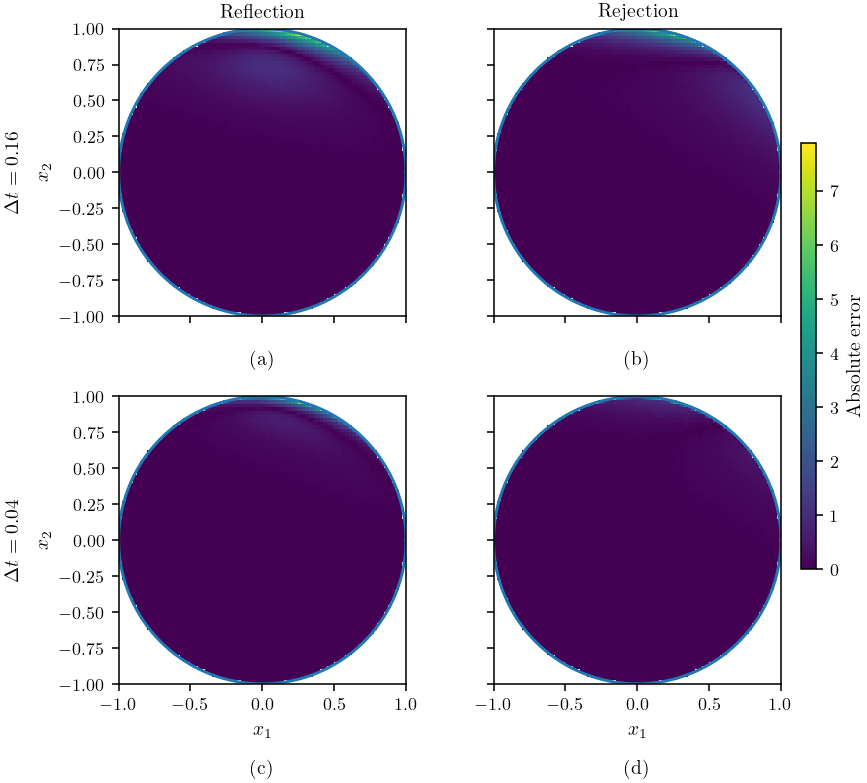

,boundary_type,dt,epsilon,L1_error,L2_error,relative_error
0,reflection,0.16,0.4,0.539711,1.014375,0.534757
1,reflection,0.04,0.2,0.233531,0.578286,0.304860
2,rejection,0.16,0.4,0.413982,0.795212,0.419219
3,rejection,0.04,0.2,0.154855,0.340419,0.179462


In [7]:
# Full-domain absolute local error
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 80

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

dt_list = [
    0.16,
    0.04
]

panel_labels = [
    [r"(a)", r"(b)"],
    [r"(c)", r"(d)"]
]

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Compute error fields
# ============================================================

full_error_rows = []
plot_data = {}

vmax = 0.0


for boundary_type in boundary_types:

    plot_data[boundary_type] = {}

    for dt in dt_list:

        # Load numerical solution
        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        # Numerical density
        p_num, x_edges, y_edges = histogram_density_disk(
            X,
            radius=radius,
            bins=bins
        )

        # Cartesian bin centres
        x_centres = 0.5 * (
            x_edges[:-1] + x_edges[1:]
        )

        y_centres = 0.5 * (
            y_edges[:-1] + y_edges[1:]
        )

        x_mesh, y_mesh = np.meshgrid(
            x_centres,
            y_centres,
            indexing="ij"
        )

        # Stationary reference solution
        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        # Local error
        error = local_error_density(
            p_num,
            p_true
        )

        abs_error = np.abs(error)

        # Error measures for later convergence analysis
        L1_error, L2_error, relative_error = density_error_norms_cartesian(
            error,
            p_true,
            x_edges,
            y_edges
        )

        full_error_rows.append({
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": np.sqrt(dt),
            "L1_error": L1_error,
            "L2_error": L2_error,
            "relative_error": relative_error
        })

        plot_data[boundary_type][dt] = (
            abs_error,
            x_edges,
            y_edges
        )

        vmax = max(
            vmax,
            np.nanmax(abs_error)
        )


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = (
    0.0,
    vmax
)


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        2,
        2,
        figsize=scaled_figsize(
            FIGSIZE_2D_2X2,
            figure_scale
        ),
        sharex=True,
        sharey=True
    )


    for row, dt in enumerate(dt_list):

        for col, boundary_type in enumerate(boundary_types):

            abs_error, x_edges, y_edges = (
                plot_data[boundary_type][dt]
            )

            report_plot_density_disk(
                abs_error,
                x_edges,
                y_edges,
                radius=radius,
                ax=ax[row, col],
                title=None,
                colorbar_values=colorbar_values,
                cmap=cmap
            )

            # Column titles
            if row == 0:
                ax[row, col].set_title(
                    boundary_name[boundary_type]
                )

            # Remove helper labels;
            # add only the layout-specific ones below.
            ax[row, col].set_xlabel("")
            ax[row, col].set_ylabel("")


    # ========================================================
    # Axis labels
    # ========================================================

    # One x1 label for each bottom subplot
    ax[1, 0].set_xlabel(r"$x_1$")
    ax[1, 1].set_xlabel(r"$x_1$")

    # One x2 label for each row
    ax[0, 0].set_ylabel(r"$x_2$")
    ax[1, 0].set_ylabel(r"$x_2$")


    # ========================================================
    # Final subplot layout
    # ========================================================

    fig.subplots_adjust(
        left=0.16,
        right=0.87,
        top=0.92,
        bottom=0.14,
        wspace=0.10,
        hspace=0.28
    )


    # ========================================================
    # Geometry-aware annotations
    # ========================================================

    fig.canvas.draw()

    all_axes = ax.ravel().tolist()

    left = min(a.get_position().x0 for a in all_axes)
    right = max(a.get_position().x1 for a in all_axes)
    bottom = min(a.get_position().y0 for a in all_axes)
    top = max(a.get_position().y1 for a in all_axes)

    # Row centres
    row0_box = ax[0, 0].get_position()
    row1_box = ax[1, 0].get_position()

    row0_center_y = row0_box.y0 + 0.5 * row0_box.height
    row1_center_y = row1_box.y0 + 0.5 * row1_box.height

    # --------------------------------------------------------
    # Row labels: placed safely left of the y-axis labels
    # --------------------------------------------------------

    row_label_x = left - 0.105

    fig.text(
        row_label_x,
        row0_center_y,
        r"$\Delta t = 0.16$",
        rotation=90,
        ha="center",
        va="center"
    )

    fig.text(
        row_label_x,
        row1_center_y,
        r"$\Delta t = 0.04$",
        rotation=90,
        ha="center",
        va="center"
    )


    # --------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------

    for row in range(2):

        for col in range(2):

            box = ax[row, col].get_position()

            if row == 0:
                label_y = box.y0 - 0.040
            else:
                label_y = box.y0 - 0.090

            fig.text(
                box.x0 + box.width / 2,
                label_y,
                panel_labels[row][col],
                ha="center",
                va="top"
            )


    # --------------------------------------------------------
    # Shared colourbar
    #
    # Shorter than the full panel block and vertically centred.
    # --------------------------------------------------------

    cbar_gap = 0.020
    cbar_width = 0.015

    block_height = top - bottom
    cbar_height = 0.65 * block_height
    cbar_bottom = bottom + 0.5 * (block_height - cbar_height)

    cax = fig.add_axes([
        right + cbar_gap,
        cbar_bottom,
        cbar_width,
        cbar_height
    ])

    mappable = ScalarMappable(
        norm=Normalize(
            vmin=colorbar_values[0],
            vmax=colorbar_values[1]
        ),
        cmap=cmap
    )

    cbar = fig.colorbar(
        mappable,
        cax=cax
    )

    cbar.set_label(r"Absolute error")


    # ========================================================
    # Save
    # ========================================================

    dt_tag = "_".join(
        f"{dt:g}" for dt in dt_list
    )

    save_report_2d_figure(
        fig,
        f"full_domain_error_dt-{dt_tag}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Numerical error table
# ============================================================

full_error_table = pd.DataFrame(
    full_error_rows
)

display(full_error_table)

### boundary stirp

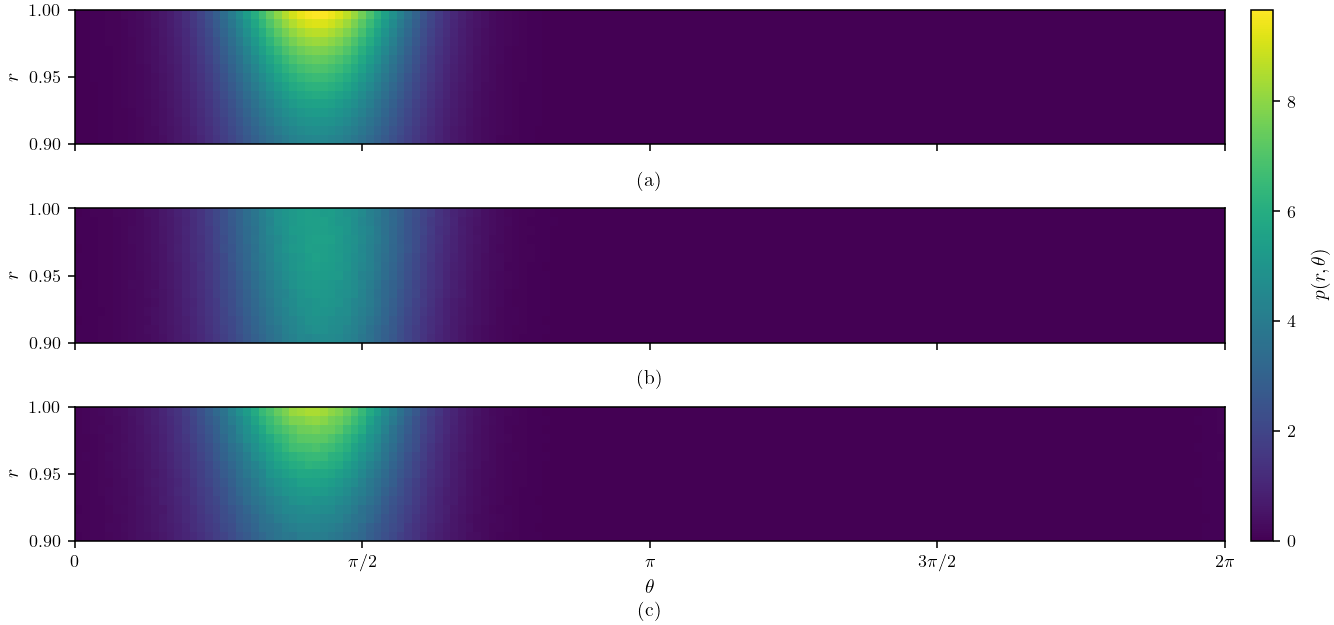

In [8]:
# Boundary-strip density
# Anisotropic diffusion in the unit disk

radius = 1.0
boundary_width = 0.1
dt = 0.04

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

panel_labels = [
    r"(a)",
    r"(b)",
    r"(c)"
]

theta_bins = 150
r_bins = 15

r_range = (
    radius - boundary_width,
    radius
)

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Numerical boundary-strip densities
# ============================================================

density_data = {}

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, theta_edges, r_edges, counts = density_disk_range(
        X,
        r_range=r_range,
        theta_bins=theta_bins,
        r_bins=r_bins
    )

    density_data[boundary_type] = p_num


# ============================================================
# Stationary reference density on the same polar grid
# ============================================================

theta_centres = 0.5 * (
    theta_edges[:-1] + theta_edges[1:]
)

r_centres = 0.5 * (
    r_edges[:-1] + r_edges[1:]
)

theta_mesh, r_mesh = np.meshgrid(
    theta_centres,
    r_centres,
    indexing="ij"
)

x_mesh = r_mesh * np.cos(theta_mesh)
y_mesh = r_mesh * np.sin(theta_mesh)

p_true = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)

density_data["exact"] = p_true


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = get_colorbar_values_2d([
    density_data["exact"],
    density_data["reflection"],
    density_data["rejection"]
])


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        3,
        1,
        figsize=scaled_figsize(
            (10.4, 4.8),
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    plot_data = [
        density_data["exact"],
        density_data["reflection"],
        density_data["rejection"]
    ]

    for i, density in enumerate(plot_data):

        report_plot_density_polar(
            density,
            theta_edges,
            r_edges,
            ax=ax[i],
            title=None,
            colorbar_values=colorbar_values,
            cmap=cmap
        )

        # Remove helper defaults and enforce report layout
        ax[i].set_xlabel("")
        ax[i].set_ylabel(r"$r$")
        ax[i].grid(False)


    # ========================================================
    # Bottom x-axis label
    # ========================================================

    ax[-1].set_xlabel(r"$\theta$")


    # ========================================================
    # Theta ticks
    # ========================================================

    theta_tick_positions = [
        0,
        np.pi / 2,
        np.pi,
        3 * np.pi / 2,
        2 * np.pi
    ]

    theta_tick_labels = [
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
        r"$3\pi/2$",
        r"$2\pi$"
    ]

    for a in ax:
        a.set_xticks(theta_tick_positions)

    ax[-1].set_xticklabels(
        theta_tick_labels
    )


    # ========================================================
    # Final subplot layout
    # ========================================================

    fig.subplots_adjust(
        left=0.10,
        right=0.89,
        top=0.97,
        bottom=0.18,
        hspace=0.48
    )


    # ========================================================
    # Panel labels
    # ========================================================

    fig.canvas.draw()

    for i in range(3):

        box = ax[i].get_position()

        if i < 2:
            label_y = box.y0 - 0.040
        else:
            label_y = box.y0 - 0.090

        fig.text(
            box.x0 + box.width / 2,
            label_y,
            panel_labels[i],
            ha="center",
            va="top"
        )


    # ========================================================
    # Shared colourbar
    # ========================================================

    report_add_shared_colorbar(
        fig,
        ax,
        colorbar_values,
        cmap=cmap,
        label=r"$p(r,\theta)$",
        gap=0.018,
        width=0.015
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        f"strip_plot_dt-{dt:g}"
    )

    plt.show()
    plt.close(fig)

### radial error

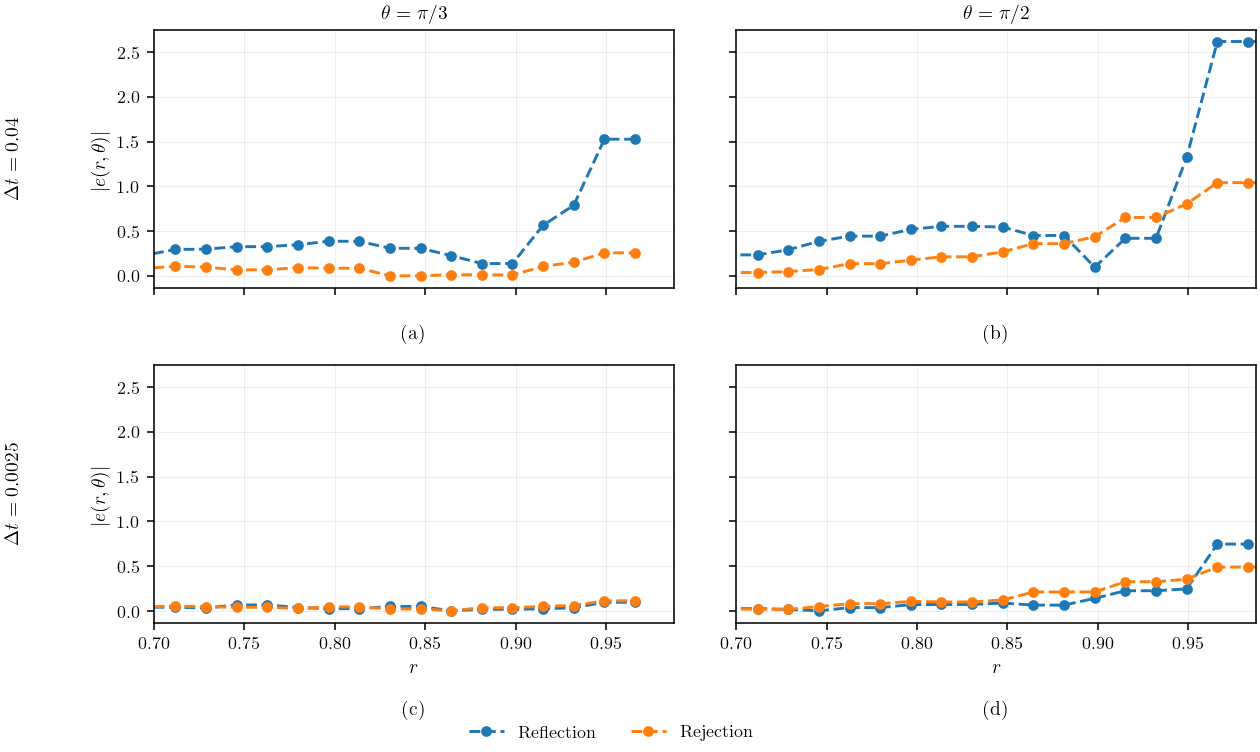

In [9]:
# Full-domain absolute error radial slices
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 80
r_bins = 60

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

boundary_color = {
    "reflection": COLOR_REFLECTION,
    "rejection": COLOR_REJECTION
}

dt_list = [
    0.04,
    0.0025
]

angles = [
    np.pi / 3,
    np.pi / 2
]

angle_labels = [
    r"$\theta = \pi/3$",
    r"$\theta = \pi/2$"
]

panel_labels = [
    [r"(a)", r"(b)"],
    [r"(c)", r"(d)"]
]

# Figure-specific scale
figure_scale = 1.0


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        2,
        2,
        figsize=scaled_figsize(
            (9.6, 5.8),
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    ax = np.atleast_2d(ax)

    reflection_line = None
    rejection_line = None

    for row, dt in enumerate(dt_list):

        error_data = {}

        # ====================================================
        # Compute full-domain error fields
        # ====================================================

        for boundary_type in boundary_types:

            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            p_num, x_edges, y_edges = histogram_density_disk(
                X,
                radius=radius,
                bins=bins
            )

            # Cartesian bin centres
            x_centres = 0.5 * (
                x_edges[:-1] + x_edges[1:]
            )

            y_centres = 0.5 * (
                y_edges[:-1] + y_edges[1:]
            )

            x_mesh, y_mesh = np.meshgrid(
                x_centres,
                y_centres,
                indexing="ij"
            )

            # Stationary solution
            p_true = stationary_solution_disk(
                x_mesh,
                y_mesh,
                b,
                sigma,
                radius=radius
            )

            # Absolute local error
            error_data[boundary_type] = np.abs(
                local_error_density(
                    p_num,
                    p_true
                )
            )

        # ====================================================
        # Radial slices
        # ====================================================

        for col, theta_0 in enumerate(angles):

            for boundary_type in boundary_types:

                r, values = field_disk_radial_slice(
                    error_data[boundary_type],
                    x_edges,
                    y_edges,
                    theta_0=theta_0,
                    radius=radius,
                    r_bins=r_bins
                )

                # Remove masked Cartesian cells
                valid = np.isfinite(values)

                r_plot = r[valid]
                values_plot = values[valid]

                line, = ax[row, col].plot(
                    r_plot,
                    values_plot,
                    color=boundary_color[boundary_type],
                    marker="o",
                    linestyle="--",
                    label=boundary_name[boundary_type]
                )

                if boundary_type == "reflection":
                    reflection_line = line
                else:
                    rejection_line = line

            # Column titles
            if row == 0:
                ax[row, col].set_title(
                    angle_labels[col]
                )

            ax[row, col].grid(True)

    # ========================================================
    # Radial plotting range
    # ========================================================

    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]

    r_plot_max = (
        radius
        - 0.5 * min(dx, dy)
    )

    for a in ax.ravel():
        a.set_xlim(
            0.7,
            r_plot_max
        )

    # ========================================================
    # Axis labels
    # ========================================================

    # One r-label per column
    ax[1, 0].set_xlabel(r"$r$")
    ax[1, 1].set_xlabel(r"$r$")

    # One error label per row
    ax[0, 0].set_ylabel(
        r"$|e(r,\theta)|$"
    )

    ax[1, 0].set_ylabel(
        r"$|e(r,\theta)|$"
    )

    # ========================================================
    # Final subplot layout
    # ========================================================

    fig.subplots_adjust(
        left=0.16,
        right=0.98,
        top=0.91,
        bottom=0.18,
        wspace=0.12,
        hspace=0.30
    )

    # ========================================================
    # Geometry-aware labels
    # ========================================================

    fig.canvas.draw()

    all_axes = ax.ravel().tolist()

    left = min(
        a.get_position().x0
        for a in all_axes
    )

    # Row centres
    row0_box = ax[0, 0].get_position()
    row1_box = ax[1, 0].get_position()

    row0_center_y = (
        row0_box.y0
        + 0.5 * row0_box.height
    )

    row1_center_y = (
        row1_box.y0
        + 0.5 * row1_box.height
    )

    # --------------------------------------------------------
    # Time-step row labels
    # --------------------------------------------------------

    row_label_x = left - 0.105

    fig.text(
        row_label_x,
        row0_center_y,
        r"$\Delta t = 0.04$",
        rotation=90,
        ha="center",
        va="center"
    )

    fig.text(
        row_label_x,
        row1_center_y,
        r"$\Delta t = 0.0025$",
        rotation=90,
        ha="center",
        va="center"
    )

    # --------------------------------------------------------
    # Panel labels
    # --------------------------------------------------------

    for row in range(2):

        for col in range(2):

            box = ax[row, col].get_position()

            if row == 0:
                label_y = box.y0 - 0.045
            else:
                label_y = box.y0 - 0.095

            fig.text(
                box.x0 + box.width / 2,
                label_y,
                panel_labels[row][col],
                ha="center",
                va="top"
            )

    # ========================================================
    # Shared legend
    # ========================================================

    fig.legend(
        handles=[
            reflection_line,
            rejection_line
        ],
        labels=[
            r"Reflection",
            r"Rejection"
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=2
    )

    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        "radial_error_dt-0.04-0.0025"
    )

    plt.show()
    plt.close(fig)

### boundary error strip

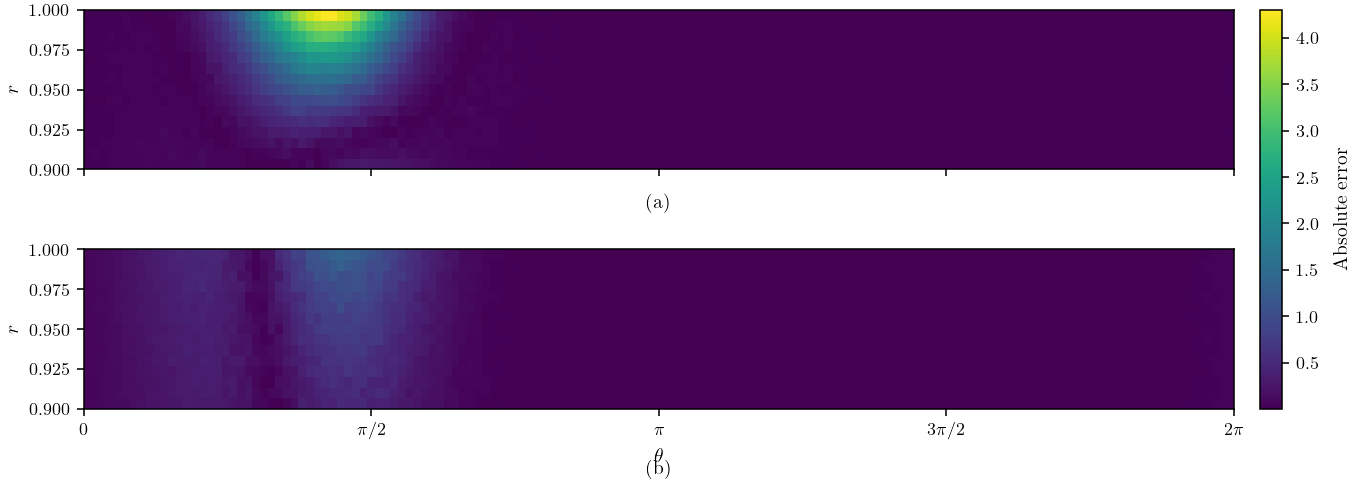

In [10]:
# Boundary-strip absolute error
# Anisotropic diffusion in the unit disk

radius = 1.0
boundary_width = 0.1
dt = 0.04

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

panel_labels = [
    r"(a)",
    r"(b)"
]

theta_bins = 150
r_bins = 15

r_range = (
    radius - boundary_width,
    radius
)

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Numerical boundary-strip densities
# ============================================================

density_data = {}

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, theta_edges, r_edges, counts = density_disk_range(
        X,
        r_range=r_range,
        theta_bins=theta_bins,
        r_bins=r_bins
    )

    density_data[boundary_type] = p_num


# ============================================================
# Stationary reference density on the same polar grid
# ============================================================

theta_centres = 0.5 * (
    theta_edges[:-1] + theta_edges[1:]
)

r_centres = 0.5 * (
    r_edges[:-1] + r_edges[1:]
)

theta_mesh, r_mesh = np.meshgrid(
    theta_centres,
    r_centres,
    indexing="ij"
)

x_mesh = r_mesh * np.cos(theta_mesh)
y_mesh = r_mesh * np.sin(theta_mesh)

p_true = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)


# ============================================================
# Absolute error on the boundary strip
# ============================================================

error_data = {
    "reflection": np.abs(
        density_data["reflection"] - p_true
    ),
    "rejection": np.abs(
        density_data["rejection"] - p_true
    )
}


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = get_colorbar_values_2d([
    error_data["reflection"],
    error_data["rejection"]
])


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        2,
        1,
        figsize=scaled_figsize(
            (10.4, 3.8),
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    plot_data = [
        error_data["reflection"],
        error_data["rejection"]
    ]

    for i, error in enumerate(plot_data):

        report_plot_density_polar(
            error,
            theta_edges,
            r_edges,
            ax=ax[i],
            title=None,
            colorbar_values=colorbar_values,
            cmap=cmap
        )

        # Enforce report layout
        ax[i].set_xlabel("")
        ax[i].set_ylabel(r"$r$")
        ax[i].grid(False)


    # ========================================================
    # Bottom x-axis label
    # ========================================================

    ax[-1].set_xlabel(r"$\theta$")


    # ========================================================
    # Theta ticks
    # ========================================================

    theta_tick_positions = [
        0,
        np.pi / 2,
        np.pi,
        3 * np.pi / 2,
        2 * np.pi
    ]

    theta_tick_labels = [
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
        r"$3\pi/2$",
        r"$2\pi$"
    ]

    for a in ax:
        a.set_xticks(theta_tick_positions)

    ax[-1].set_xticklabels(
        theta_tick_labels
    )


    # ========================================================
    # Final subplot layout
    # ========================================================

    fig.subplots_adjust(
        left=0.10,
        right=0.89,
        top=0.97,
        bottom=0.22,
        hspace=0.50
    )


    # ========================================================
    # Panel labels
    # ========================================================

    fig.canvas.draw()

    for i in range(2):

        box = ax[i].get_position()

        if i == 0:
            label_y = box.y0 - 0.045
        else:
            label_y = box.y0 - 0.095

        fig.text(
            box.x0 + box.width / 2,
            label_y,
            panel_labels[i],
            ha="center",
            va="top"
        )


    # ========================================================
    # Shared colourbar
    # ========================================================

    report_add_shared_colorbar(
        fig,
        ax,
        colorbar_values,
        cmap=cmap,
        label=r"Absolute error",
        gap=0.018,
        width=0.015
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        f"strip_error_dt-{dt:g}"
    )

    plt.show()
    plt.close(fig)

### Convergence plot

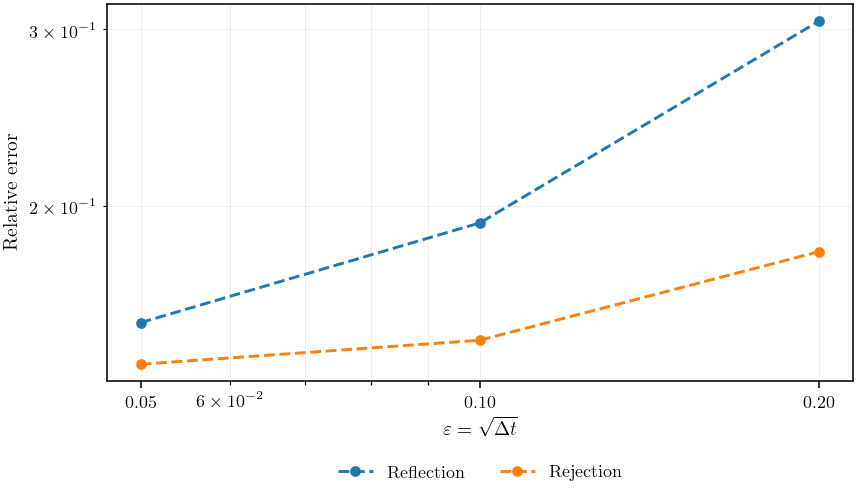

,boundary_type,observed_order
0,Reflection,0.500659
1,Rejection,0.187003


In [11]:
# Full-domain convergence
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 100

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

boundary_color = {
    "reflection": COLOR_REFLECTION,
    "rejection": COLOR_REJECTION
}

dt_list = [
    0.04,
    0.01,
    0.0025
]

# Figure-specific scale
figure_scale = 1.0

full_error_rows = []


# ============================================================
# Compute full-domain errors
# ============================================================

for boundary_type in boundary_types:

    for dt in dt_list:

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, x_edges, y_edges = histogram_density_disk(
            X,
            radius=radius,
            bins=bins
        )

        # Cartesian bin centres
        x_centres = 0.5 * (
            x_edges[:-1] + x_edges[1:]
        )

        y_centres = 0.5 * (
            y_edges[:-1] + y_edges[1:]
        )

        x_mesh, y_mesh = np.meshgrid(
            x_centres,
            y_centres,
            indexing="ij"
        )

        # Stationary reference solution
        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        # Local error
        error = local_error_density(
            p_num,
            p_true
        )

        # Error norms
        L1_error, L2_error, relative_error = density_error_norms_cartesian(
            error,
            p_true,
            x_edges,
            y_edges
        )

        full_error_rows.append({
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": np.sqrt(dt),
            "relative_error": relative_error
        })


# Results table used for plotting
full_error_table = pd.DataFrame(
    full_error_rows
)


# ============================================================
# Plot
# ============================================================

order_rows = []

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        figsize=scaled_figsize(
            FIGSIZE_SINGLE,
            figure_scale
        )
    )

    for boundary_type in boundary_types:

        rows = full_error_table[
            full_error_table["boundary_type"]
            == boundary_type
        ].sort_values(
            "epsilon"
        )

        epsilon_values = rows[
            "epsilon"
        ].to_numpy()

        errors = rows[
            "relative_error"
        ].to_numpy()

        # Observed convergence order
        order = np.polyfit(
            np.log(epsilon_values),
            np.log(errors),
            1
        )[0]

        order_rows.append({
            "boundary_type": boundary_name[boundary_type],
            "observed_order": order
        })

        # Convergence curve
        ax.loglog(
            epsilon_values,
            errors,
            marker="o",
            linestyle="--",
            color=boundary_color[boundary_type],
            label=boundary_name[boundary_type]
        )


    # ========================================================
    # Axis formatting
    # ========================================================

    ax.set_xlabel(
        r"$\varepsilon = \sqrt{\Delta t}$"
    )

    ax.set_ylabel(
        r"Relative error"
    )

    # Use the actual epsilon values as labelled major ticks
    ax.set_xticks([
        0.05,
        0.10,
        0.20
    ])

    ax.set_xticklabels([
        r"$0.05$",
        r"$0.10$",
        r"$0.20$"
    ])

    # Major and minor log-grid lines
    ax.grid(
        True,
        which="both"
    )


    # ========================================================
    # Shared legend below plot
    # ========================================================

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2
    )


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.96,
        bottom=0.25
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        f"convergance_full"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Observed convergence orders
# ============================================================

full_convergence_table = pd.DataFrame(
    order_rows
)

display(full_convergence_table)

### convergence over the strip

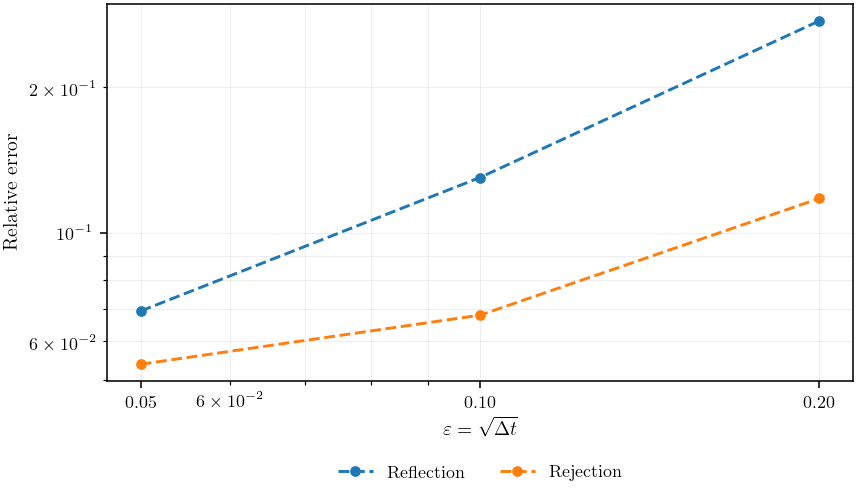

,boundary_type,observed_order
0,Reflection,0.992480
1,Rejection,0.567127


In [12]:
# Boundary-strip convergence
# Anisotropic diffusion in the unit disk

radius = 1.0
boundary_width = 0.1

theta_bins = 150
r_bins = 15

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

boundary_color = {
    "reflection": COLOR_REFLECTION,
    "rejection": COLOR_REJECTION
}

dt_list = [
    0.04,
    0.01,
    0.0025
]

r_range = (
    radius - boundary_width,
    radius
)

# Figure-specific scale
figure_scale = 1.0

boundary_error_rows = []


# ============================================================
# Compute boundary-strip errors
# ============================================================

for boundary_type in boundary_types:

    for dt in dt_list:

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, theta_edges, r_edges, counts = density_disk_range(
            X,
            r_range=r_range,
            theta_bins=theta_bins,
            r_bins=r_bins
        )

        theta_centres = 0.5 * (
            theta_edges[:-1] + theta_edges[1:]
        )

        r_centres = 0.5 * (
            r_edges[:-1] + r_edges[1:]
        )

        theta_mesh, r_mesh = np.meshgrid(
            theta_centres,
            r_centres,
            indexing="ij"
        )

        x_mesh = r_mesh * np.cos(theta_mesh)
        y_mesh = r_mesh * np.sin(theta_mesh)

        # Stationary reference solution
        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        # Local error
        error = local_error_density(
            p_num,
            p_true
        )

        # Error norms
        L1_error, L2_error, relative_error = density_error_norms(
            error,
            p_true,
            theta_edges,
            r_edges
        )

        boundary_error_rows.append({
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": np.sqrt(dt),
            "relative_error": relative_error
        })


# Results table used for plotting
boundary_error_table = pd.DataFrame(
    boundary_error_rows
)


# ============================================================
# Plot
# ============================================================

order_rows = []

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        figsize=scaled_figsize(
            FIGSIZE_SINGLE,
            figure_scale
        )
    )

    for boundary_type in boundary_types:

        rows = boundary_error_table[
            boundary_error_table["boundary_type"]
            == boundary_type
        ].sort_values(
            "epsilon"
        )

        epsilon_values = rows[
            "epsilon"
        ].to_numpy()

        errors = rows[
            "relative_error"
        ].to_numpy()

        # Observed convergence order
        order = np.polyfit(
            np.log(epsilon_values),
            np.log(errors),
            1
        )[0]

        order_rows.append({
            "boundary_type": boundary_name[boundary_type],
            "observed_order": order
        })

        # Convergence curve
        ax.loglog(
            epsilon_values,
            errors,
            marker="o",
            linestyle="--",
            color=boundary_color[boundary_type],
            label=boundary_name[boundary_type]
        )


    # ========================================================
    # Axis formatting
    # ========================================================

    ax.set_xlabel(
        r"$\varepsilon = \sqrt{\Delta t}$"
    )

    ax.set_ylabel(
        r"Relative error"
    )

    ax.set_xticks([
        0.05,
        0.10,
        0.20
    ])

    ax.set_xticklabels([
        r"$0.05$",
        r"$0.10$",
        r"$0.20$"
    ])

    ax.grid(
        True,
        which="both"
    )


    # ========================================================
    # Legend below plot
    # ========================================================

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2
    )


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.96,
        bottom=0.25
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        f"convergance boundary"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Observed convergence orders
# ============================================================

boundary_convergence_table = pd.DataFrame(
    order_rows
)

display(boundary_convergence_table)

### stretched boundary

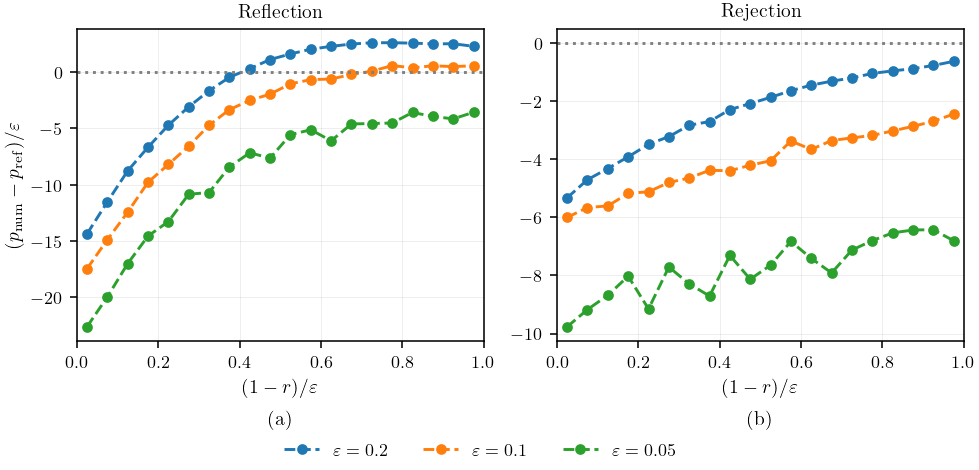

In [13]:
# Stretched boundary-layer error profiles
# Averaged over a small angular wedge around theta = pi/2

radius = 1.0

b = np.array([1.0, 1.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-1-1_s-M"

boundary_types = [
    "reflection",
    "rejection"
]

boundary_titles = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

dt_list = [
    0.04,
    0.01,
    0.0025
]

theta_0 = np.pi / 2
theta_half_width = np.pi / 18   # +/- 10 degrees

theta_bins = 180
r_bins = 20

panel_labels = [
    r"(a)",
    r"(b)"
]

# Figure-specific scale
figure_scale = 1.0


# ============================================================
# Compute stretched profiles
# ============================================================

profile_data = {}

for boundary_type in boundary_types:

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        # Physical boundary strip of width epsilon
        r_range = (
            radius - epsilon,
            radius
        )

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, theta_edges, r_edges, counts = density_disk_range(
            X,
            r_range=r_range,
            theta_bins=theta_bins,
            r_bins=r_bins
        )

        # Bin centres
        theta_centres = 0.5 * (
            theta_edges[:-1] + theta_edges[1:]
        )

        r_centres = 0.5 * (
            r_edges[:-1] + r_edges[1:]
        )

        # Stationary reference density on the same polar grid
        theta_mesh, r_mesh = np.meshgrid(
            theta_centres,
            r_centres,
            indexing="ij"
        )

        x_mesh = r_mesh * np.cos(theta_mesh)
        y_mesh = r_mesh * np.sin(theta_mesh)

        p_ref = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        # Angular wedge around theta = pi/2
        theta_mask = (
            (theta_centres >= theta_0 - theta_half_width)
            &
            (theta_centres <= theta_0 + theta_half_width)
        )

        if not np.any(theta_mask):
            raise ValueError(
                "Angular wedge is empty. "
                "Increase theta_bins or theta_half_width."
            )

        # Wedge-averaged radial profiles
        p_num_profile = np.nanmean(
            p_num[theta_mask, :],
            axis=0
        )

        p_ref_profile = np.nanmean(
            p_ref[theta_mask, :],
            axis=0
        )

        # Signed scaled error
        scaled_error = (
            p_num_profile - p_ref_profile
        ) / epsilon

        # Stretched coordinate rho = (1-r)/epsilon
        rho = (
            radius - r_centres
        ) / epsilon

        # Sort so rho increases from 0 to 1
        order = np.argsort(rho)

        profile_data[(boundary_type, dt)] = {
            "rho": rho[order],
            "error": scaled_error[order]
        }


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        1,
        2,
        figsize=scaled_figsize(
            FIGSIZE_DOUBLE,
            figure_scale
        ),
        sharex=True
    )

    # Use the same colours for each epsilon in both panels
    epsilon_colors = {}

    for i, boundary_type in enumerate(boundary_types):

        for j, dt in enumerate(dt_list):

            epsilon = np.sqrt(dt)

            data = profile_data[
                (boundary_type, dt)
            ]

            line, = ax[i].plot(
                data["rho"],
                data["error"],
                marker="o",
                linestyle="--",
                label=fr"$\varepsilon = {epsilon:g}$"
            )

            # Record colour from the first panel
            if i == 0:
                epsilon_colors[dt] = line.get_color()

            # Reuse the same colour in the second panel
            else:
                line.set_color(
                    epsilon_colors[dt]
                )

        # Zero reference line
        ax[i].axhline(
            0,
            linestyle=":",
            color="0.5"
        )

        ax[i].set_title(
            boundary_titles[boundary_type]
        )

        ax[i].set_xlim(
            0,
            1
        )

        ax[i].set_xlabel(
            r"$(1-r)/\varepsilon$"
        )

        ax[i].grid(
            True
        )


    # ========================================================
    # Axis labels
    # ========================================================

    ax[0].set_ylabel(
        r"$(p_{\mathrm{num}}-p_{\mathrm{ref}})/\varepsilon$"
    )


    # ========================================================
    # Panel labels
    # ========================================================

    for i in range(2):

        ax[i].text(
            0.5,
            -0.22,
            panel_labels[i],
            transform=ax[i].transAxes,
            ha="center",
            va="top"
        )


    # ========================================================
    # Shared legend
    # ========================================================

    handles, labels = ax[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=3
    )


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.90,
        bottom=0.28,
        wspace=0.18
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        "error_stretched_profile"
    )

    plt.show()
    plt.close(fig)

## Normal vs Oblique reflection

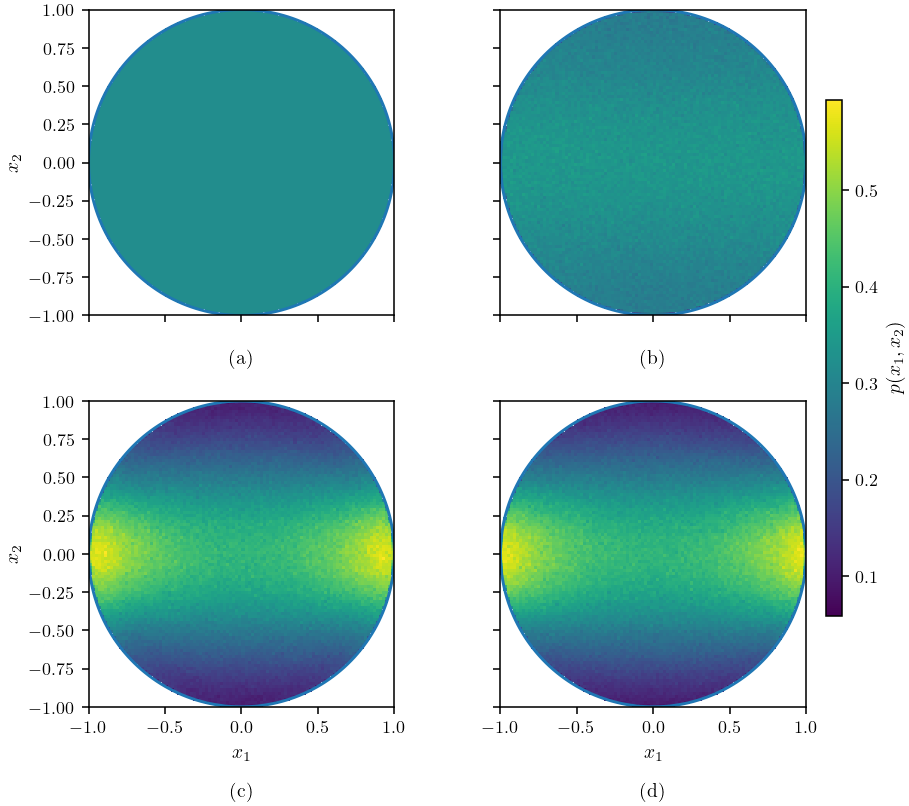

In [14]:
# Normal vs oblique reflection
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 100

b = np.array([0.0, 0.0])

sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-0_s-M"

dt_oblique = 0.01
dt_normal_1 = 0.01
dt_normal_2 = 0.0025

panel_labels = [
    [r"(a)", r"(b)"],
    [r"(c)", r"(d)"]
]

# Figure-specific scale
figure_scale = 1.0

cmap = REPORT_CMAP


# ============================================================
# Stationary reference density
# ============================================================

x_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

y_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

x_centres = 0.5 * (
    x_edges[:-1] + x_edges[1:]
)

y_centres = 0.5 * (
    y_edges[:-1] + y_edges[1:]
)

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)

p_ref = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)


# ============================================================
# Oblique reflection
# ============================================================

X_oblique = load_solution(
    f"reflection_dt-{dt_oblique}.npy",
    problem_path
)

p_oblique, _, _ = histogram_density_disk(
    X_oblique,
    radius=radius,
    bins=bins
)


# ============================================================
# Forced normal reflection
# ============================================================

X_normal_1 = load_solution(
    f"reflect_norm_dt-{dt_normal_1}.npy",
    problem_path
)

p_normal_1, _, _ = histogram_density_disk(
    X_normal_1,
    radius=radius,
    bins=bins
)


X_normal_2 = load_solution(
    f"reflect_norm_dt-{dt_normal_2}.npy",
    problem_path
)

p_normal_2, _, _ = histogram_density_disk(
    X_normal_2,
    radius=radius,
    bins=bins
)


# ============================================================
# Shared colour scale
# ============================================================

colorbar_values = get_colorbar_values_2d([
    p_ref,
    p_oblique,
    p_normal_1,
    p_normal_2
])


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    scaled_plot_style(figure_scale)
):

    fig, ax = plt.subplots(
        2,
        2,
        figsize=scaled_figsize(
            FIGSIZE_2D_2X2,
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    plot_data = [
        [p_ref, p_oblique],
        [p_normal_1, p_normal_2]
    ]

    for row in range(2):

        for col in range(2):

            report_plot_density_disk(
                plot_data[row][col],
                x_edges,
                y_edges,
                radius=radius,
                ax=ax[row, col],
                title=None,
                colorbar_values=colorbar_values,
                cmap=cmap,
                show_boundary=True
            )

            ax[row, col].grid(False)


    # ========================================================
    # Axis labels
    # ========================================================

    # x_1 only on bottom row
    ax[1, 0].set_xlabel(r"$x_1$")
    ax[1, 1].set_xlabel(r"$x_1$")

    ax[0, 0].set_xlabel("")
    ax[0, 1].set_xlabel("")

    # x_2 only on left column
    ax[0, 0].set_ylabel(r"$x_2$")
    ax[1, 0].set_ylabel(r"$x_2$")

    ax[0, 1].set_ylabel("")
    ax[1, 1].set_ylabel("")


    # ========================================================
    # Final subplot layout
    # ========================================================

    fig.subplots_adjust(
        left=0.09,
        right=0.87,
        top=0.97,
        bottom=0.14,
        wspace=0.10,
        hspace=0.28
    )


    # ========================================================
    # Geometry-aware panel labels
    # ========================================================

    fig.canvas.draw()

    for row in range(2):

        for col in range(2):

            box = ax[row, col].get_position()

            if row == 0:
                label_y = box.y0 - 0.040
            else:
                label_y = box.y0 - 0.090

            fig.text(
                box.x0 + box.width / 2,
                label_y,
                panel_labels[row][col],
                ha="center",
                va="top"
            )


    # ========================================================
    # Shared colourbar
    # ========================================================

    all_axes = ax.ravel().tolist()

    right = max(
        a.get_position().x1
        for a in all_axes
    )

    bottom = min(
        a.get_position().y0
        for a in all_axes
    )

    top = max(
        a.get_position().y1
        for a in all_axes
    )

    cbar_gap = 0.020
    cbar_width = 0.015

    block_height = top - bottom

    cbar_height = (
        0.74 * block_height
    )

    cbar_bottom = (
        bottom
        + 0.5 * (
            block_height
            - cbar_height
        )
    )

    cax = fig.add_axes([
        right + cbar_gap,
        cbar_bottom,
        cbar_width,
        cbar_height
    ])

    mappable = ScalarMappable(
        norm=Normalize(
            vmin=colorbar_values[0],
            vmax=colorbar_values[1]
        ),
        cmap=cmap
    )

    cbar = fig.colorbar(
        mappable,
        cax=cax
    )

    cbar.set_label(
        r"$p(x_1,x_2)$"
    )


    # ========================================================
    # Save
    # ========================================================

    save_report_2d_figure(
        fig,
        "oblique_vs_normal"
    )

    plt.show()
    plt.close(fig)

# Particle Reflection in box domain

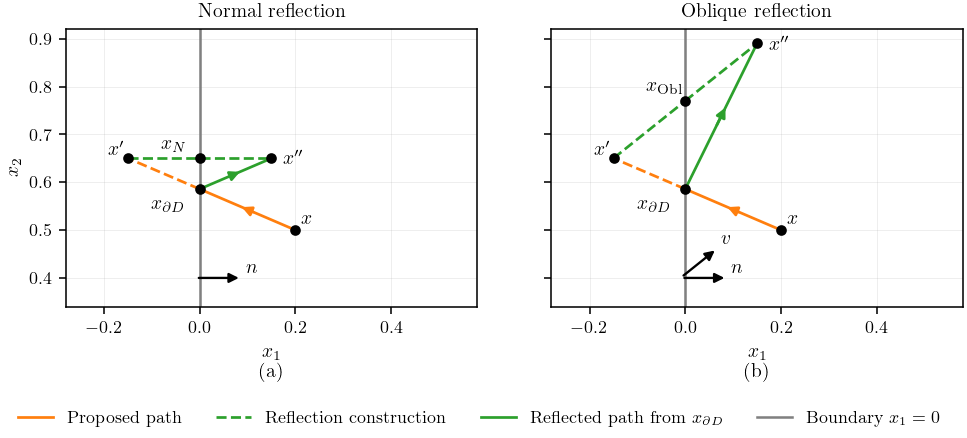

In [15]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================================================
# Normal vs oblique reflection
# Half-plane demonstration: D = {x_1 > 0}
# ============================================================

bounds = ((0, 1), (0, 1))

sigma_normal = np.eye(2)

sigma_oblique = np.array([
    [1.0, 0.5],
    [0.5, 1.0]
])

# Current point x is inside the half-plane x_1 > 0
X_current = np.array([
    [0.2, 0.50]
])

# Proposed point x' is outside the half-plane x_1 > 0
proposal = np.array([
    [-0.15, 0.65]
])

# Outward normal for D = {x_1 > 0}
normal = np.array([
    [-1.0, 0.0]
])

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


# ------------------------------------------------------------
# First intersection of the attempted path with x_1 = 0
# This is x_{\partial D}
# ------------------------------------------------------------

def halfplane_boundary_hit(X_current, proposal):
    delta_X = proposal - X_current
    alpha = -X_current[:, 0] / delta_X[:, 0]
    X_hit = X_current + alpha[:, None] * delta_X
    return X_hit


# ------------------------------------------------------------
# Compute boundary projection point, reflected point,
# and inward reflection direction
# ------------------------------------------------------------

def compute_halfplane_reflection(proposal, normal, sigma, boundary_type):
    """
    For a proposed point outside x_1 > 0, compute:

    - x_B-type point on the boundary reached by moving from x'
      in the reflection direction,
    - reflected point x'',
    - inward unit reflection direction.
    """
    v_outward = get_reflection_direction(
        normal,
        sigma,
        boundary_type
    )

    v_inward = -v_outward
    v_inward = v_inward / np.linalg.norm(v_inward, axis=1)[:, None]

    # Move from proposal to the boundary along v_inward
    t_boundary = -proposal[:, 0] / v_inward[:, 0]
    boundary_projection = proposal + t_boundary[:, None] * v_inward

    # Reflect by continuing the same distance again
    reflected_point = proposal + 2.0 * t_boundary[:, None] * v_inward

    return boundary_projection, reflected_point, v_inward


# ------------------------------------------------------------
# Geometric data
# ------------------------------------------------------------

X_boundary = halfplane_boundary_hit(
    X_current,
    proposal
)

x_N, X_final_normal, v_normal = compute_halfplane_reflection(
    proposal,
    normal,
    sigma_normal,
    "reflect_norm"
)

x_Obl, X_final_oblique, v_oblique = compute_halfplane_reflection(
    proposal,
    normal,
    sigma_oblique,
    "reflection"
)


# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def add_midline_arrow(
    ax,
    start,
    end,
    color="black",
    arrow_fraction=0.12,
    linewidth=1.2,
    zorder=7
):
    """
    Add an arrow centred on the line segment from start to end.
    """

    start = np.asarray(start)
    end = np.asarray(end)

    direction = end - start
    midpoint = 0.5 * (start + end)

    arrow_start = midpoint - 0.5 * arrow_fraction * direction
    arrow_end = midpoint + 0.5 * arrow_fraction * direction

    ax.annotate(
        "",
        xy=arrow_end,
        xytext=arrow_start,
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            linewidth=linewidth,
            shrinkA=0,
            shrinkB=0
        ),
        zorder=zorder
    )

def draw_reflection_panel(
    ax,
    title,
    X_current,
    proposal,
    X_boundary,
    boundary_projection,
    X_final,
    normal,
    boundary_projection_label,
    panel_label,
    v_inward=None,
    show_v=False
):
    """
    Draw one reflection schematic in the half-plane x_1 = 0.
    """

    color_attempt = "tab:orange"
    color_construct = "tab:green"
    color_boundary = "grey"
    color_points = "black"
    color_vector = "black"

    point_size = 20
    line_width = 1.4

    # --------------------------------------------------------
    # Boundary line x_1 = 0
    # --------------------------------------------------------
    ax.axvline(
        0.0,
        color=color_boundary,
        linewidth=1.3
    )

    # --------------------------------------------------------
    # Proposed path: x -> x_{\partial D} -> x'
    # Solid inside domain, dashed outside domain
    # --------------------------------------------------------
    ax.plot(
        [X_current[0, 0], X_boundary[0, 0]],
        [X_current[0, 1], X_boundary[0, 1]],
        color=color_attempt,
        linestyle="-",
        linewidth=line_width
    )

    add_midline_arrow(
        ax,
        X_current[0],
        X_boundary[0],
        color=color_attempt,
        linewidth=line_width
        )

    ax.plot(
        [X_boundary[0, 0], proposal[0, 0]],
        [X_boundary[0, 1], proposal[0, 1]],
        color=color_attempt,
        linestyle="--",
        linewidth=line_width
    )

    # --------------------------------------------------------
    # Reflection construction
    # x' -> x_B-type point        dashed green
    # x_B-type point -> x''       dashed green
    # x_{\partial D} -> x''       solid green
    # --------------------------------------------------------
    ax.plot(
        [proposal[0, 0], boundary_projection[0, 0]],
        [proposal[0, 1], boundary_projection[0, 1]],
        color=color_construct,
        linestyle="--",
        linewidth=line_width
    )

    ax.plot(
        [boundary_projection[0, 0], X_final[0, 0]],
        [boundary_projection[0, 1], X_final[0, 1]],
        color=color_construct,
        linestyle="--",
        linewidth=line_width
    )

    ax.plot(
        [X_boundary[0, 0], X_final[0, 0]],
        [X_boundary[0, 1], X_final[0, 1]],
        color=color_construct,
        linestyle="-",
        linewidth=line_width
    )

    add_midline_arrow(
        ax,
        X_boundary[0],
        X_final[0],
        color=color_construct,
        linewidth=line_width
        )

    # --------------------------------------------------------
    # Points
    # --------------------------------------------------------
    ax.scatter(
        X_current[:, 0],
        X_current[:, 1],
        color=color_points,
        s=point_size,
        zorder=5
    )

    ax.scatter(
        proposal[:, 0],
        proposal[:, 1],
        color=color_points,
        s=point_size,
        zorder=5
    )

    ax.scatter(
        X_final[:, 0],
        X_final[:, 1],
        color=color_points,
        s=point_size,
        zorder=5
    )

    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        color=color_points,
        s=point_size,
        zorder=6
    )

    ax.scatter(
        boundary_projection[:, 0],
        boundary_projection[:, 1],
        color=color_points,
        s=point_size,
        zorder=6
    )

    # --------------------------------------------------------
    # Point labels
    # --------------------------------------------------------
    ax.annotate(
        r"$x$",
        xy=(X_current[0, 0], X_current[0, 1]),
        xytext=(3, 3),
        textcoords="offset points"
    )

    # x' to the left of the point
    ax.annotate(
        r"$x'$",
        xy=(proposal[0, 0], proposal[0, 1]),
        xytext=(-10, 2),
        textcoords="offset points"
    )

    # x'' to the right of the point
    ax.annotate(
        r"$x''$",
        xy=(X_final[0, 0], X_final[0, 1]),
        xytext=(6, -3),
        textcoords="offset points"
    )

    ax.annotate(
        r"$x_{\partial D}$",
        xy=(X_boundary[0, 0], X_boundary[0, 1]),
        xytext=(-25, -10),
        textcoords="offset points"
    )

    ax.annotate(
        boundary_projection_label,
        xy=(boundary_projection[0, 0], boundary_projection[0, 1]),
        xytext=(-20, 5),
        textcoords="offset points"
    )

    # --------------------------------------------------------
    # Vectors n and v
    # Both start from the same point.
    # n is the inward normal.
    # v is shown only for oblique reflection.
    # --------------------------------------------------------
    vector_anchor = np.array([-0.01, 0.4])
    vector_length = 0.1

    n_inward = -normal[0]
    n_inward = n_inward / np.linalg.norm(n_inward)

    n_end = vector_anchor + vector_length * n_inward

    ax.annotate(
        "",
        xy=(n_end[0], n_end[1]),
        xytext=(vector_anchor[0], vector_anchor[1]),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.2,
            color=color_vector
        ),
        zorder=6
    )

    ax.text(
        n_end[0] + 0.006,
        n_end[1] + 0.002,
        r"$n$",
        color=color_vector,
        ha="left",
        va="bottom"
    )

    if show_v and v_inward is not None:
        v_unit = v_inward[0] / np.linalg.norm(v_inward[0])
        v_end = vector_anchor + vector_length * v_unit

        ax.annotate(
            "",
            xy=(v_end[0], v_end[1]),
            xytext=(vector_anchor[0], vector_anchor[1]),
            arrowprops=dict(
                arrowstyle="-|>",
                linewidth=1.2,
                color=color_vector
            ),
            zorder=6
        )

        ax.text(
            v_end[0] + 0.006,
            v_end[1] + 0.002,
            r"$v$",
            color=color_vector,
            ha="left",
            va="bottom"
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
    ax.set_aspect("equal")
    ax.grid(True, axis="both")

    ax.text(
        0.5,
        -0.20,
        panel_label,
        transform=ax.transAxes,
        ha="center",
        va="top"
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        1,
        2,
        figsize=scaled_figsize(FIGSIZE_DOUBLE, figure_scale),
        sharex=True,
        sharey=True
    )

    draw_reflection_panel(
        ax=ax[0],
        title="Normal reflection",
        X_current=X_current,
        proposal=proposal,
        X_boundary=X_boundary,
        boundary_projection=x_N,
        X_final=X_final_normal,
        normal=normal,
        boundary_projection_label=r"$x_N$",
        panel_label=panel_labels[0],
        v_inward=None,
        show_v=False
    )

    draw_reflection_panel(
        ax=ax[1],
        title="Oblique reflection",
        X_current=X_current,
        proposal=proposal,
        X_boundary=X_boundary,
        boundary_projection=x_Obl,
        X_final=X_final_oblique,
        normal=normal,
        boundary_projection_label=r"$x_{\mathrm{Obl}}$",
        panel_label=panel_labels[1],
        v_inward=v_oblique,
        show_v=True
    )

    ax[0].set_ylabel(r"$x_2$")

    # Zoomed view around the reflection event
    for a in ax:
        a.set_xlim(-0.28, 0.58)
        a.set_ylim(0.34, 0.92)

    # Shared legend
    legend_handles = [
        Line2D(
            [0], [0],
            color="tab:orange",
            linewidth=1.4,
            label="Proposed path"
        ),
        Line2D(
            [0], [0],
            color="tab:green",
            linestyle="--",
            linewidth=1.4,
            label="Reflection construction"
        ),
        Line2D(
            [0], [0],
            color="tab:green",
            linestyle="-",
            linewidth=1.4,
            label=r"Reflected path from $x_{\partial D}$"
        ),
        Line2D(
            [0], [0],
            color="grey",
            linewidth=1.3,
            label=r"Boundary $x_1=0$"
        )
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.98,
        top=0.88,
        bottom=0.25,
        wspace=0.18
    )

    save_report_2d_figure(
        fig,
        "halfplane_normal_vs_oblique_reflection"
    )

    plt.show()
    plt.close(fig)